## homework: 2025 cohorts
https://github.com/DataTalksClub/machine-learning-zoomcamp/blob/master/cohorts/2025/02-regression/homework.md


In [201]:
import pandas as pd
import numpy as np

## EDA

In [202]:
df = pd.read_csv('car_fuel_efficiency.csv')
df.columns

Index(['engine_displacement', 'num_cylinders', 'horsepower', 'vehicle_weight',
       'acceleration', 'model_year', 'origin', 'fuel_type', 'drivetrain',
       'num_doors', 'fuel_efficiency_mpg'],
      dtype='str')

In [203]:
strings = list(df.dtypes[df.dtypes == 'str'].index)
strings

['origin', 'fuel_type', 'drivetrain']

In [204]:
for col in df.columns:
    if df[col].dtypes == 'str':
        print(df[col].name)
        print(df[col].unique())
        print(df[col].nunique())
        print()

origin
<StringArray>
['Europe', 'USA', 'Asia']
Length: 3, dtype: str
3

fuel_type
<StringArray>
['Gasoline', 'Diesel']
Length: 2, dtype: str
2

drivetrain
<StringArray>
['All-wheel drive', 'Front-wheel drive']
Length: 2, dtype: str
2



In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

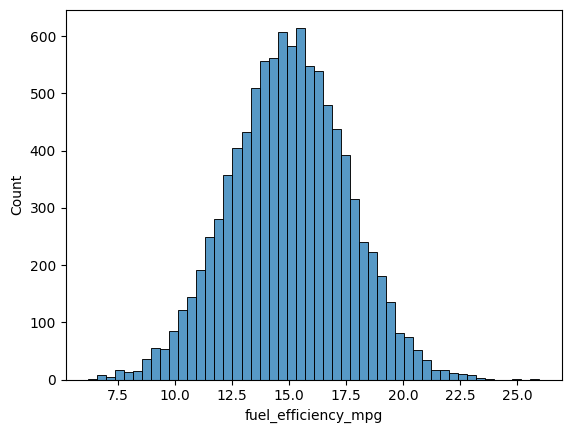

In [206]:
sns.histplot(df.fuel_efficiency_mpg, bins=50)

<Axes: xlabel='engine_displacement', ylabel='Count'>

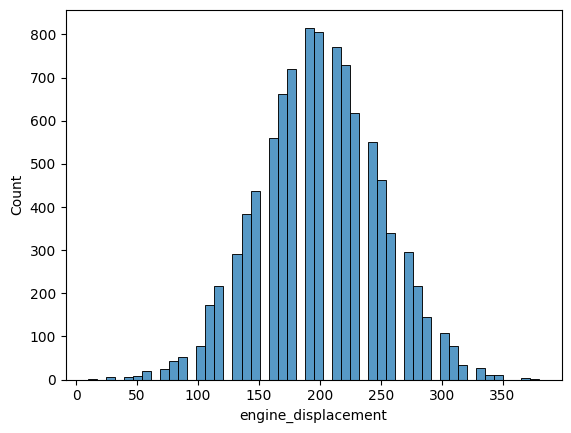

In [207]:
sns.histplot(df.engine_displacement, bins=50)

# Question 1

In [208]:
df.isnull().sum() 

engine_displacement      0
num_cylinders          482
horsepower             708
vehicle_weight           0
acceleration           930
model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors              502
fuel_efficiency_mpg      0
dtype: int64

# Question 2

In [209]:
median_hp = df['horsepower'].dropna().median() 
max_model_year = df['model_year'].max() 
median_hp, max_model_year

(np.float64(149.0), np.int64(2023))

In [210]:
# Prepare and split the dataset
n = len(df)

n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

n, n_val, n_test, n_train

(9704, 1940, 1940, 5824)

In [211]:
df.iloc[[10, 0, 3, 5]]

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
10,230,5.0,100.0,3111.810181,15.4,2014,Europe,Diesel,All-wheel drive,0.0,13.386605
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
5,190,3.0,NaN,2484.883986,14.7,2008,Europe,Gasoline,All-wheel drive,-1.0,17.271818


In [212]:
df_train = df.iloc[:n_train]
df_val = df.iloc[n_train:n_train+n_val]
df_test = df.iloc[n_train+n_val:]

In [213]:
idx = np.arange(n)

In [214]:
np.random.seed(42)
np.random.shuffle(idx)

In [215]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train+n_val:]]

In [216]:
df_train.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
483,220,3.0,144.0,2535.887591,18.7,2009,USA,Gasoline,All-wheel drive,2.0,16.642943
7506,160,2.0,141.0,2741.170484,14.3,2019,Asia,Diesel,Front-wheel drive,2.0,16.298377
8795,230,3.0,155.0,2471.880237,NaN,2017,Asia,Diesel,Front-wheel drive,2.0,18.591822
1688,150,3.0,206.0,3748.164469,15.5,2015,USA,Gasoline,All-wheel drive,1.0,11.818843
6217,300,4.0,111.0,2135.716359,16.9,2006,USA,Gasoline,All-wheel drive,NaN,19.402209


In [217]:
len(df_train), len(df_val), len(df_test)

(5824, 1940, 1940)

In [218]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

# Question 3

In [219]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [220]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
X_train = df_train[base].fillna(0).values
w0, w = train_linear_regression(X_train, y_train)
y_pred = w0 + X_train.dot(w)

In [221]:
w0

np.float64(28.82736547449205)

In [222]:
w

array([ 9.93613215e-05,  3.54221891e-03, -5.01328015e-03,  3.42992869e-04])

<Axes: ylabel='Count'>

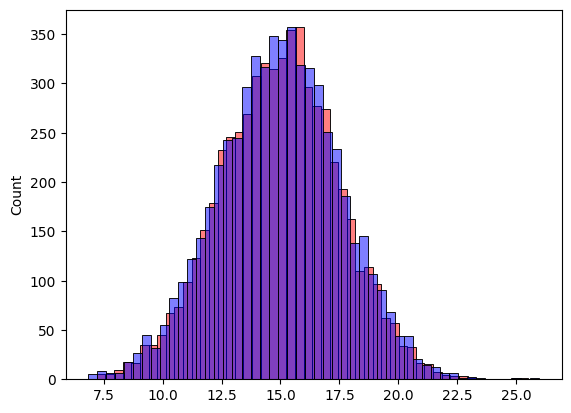

In [223]:
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)

In [224]:
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [225]:
rmse(y_train, y_pred)

np.float64(0.5202614265150717)

In [226]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [227]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
round(rmse(y_val, y_pred), 2)

np.float64(0.52)

In [228]:
# simple engineering
def prepare_X(df, fill_value):
    df = df.copy()
    df_num = df[base]
    df_num = df_num.fillna(fill_value)
    X = df_num.values

    return X

In [229]:
mean_hp_train = df_train['horsepower'].dropna().mean() 

In [230]:
# With 0
X_train = prepare_X(df_train, 0)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, 0)
y_pred = w0 + X_val.dot(w)
zero_rmse = round(rmse(y_val, y_pred), 2)

# With mean
X_train = prepare_X(df_train, df_train['horsepower'].dropna().mean())
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val, df_train['horsepower'].dropna().mean())
y_pred = w0 + X_val.dot(w)
mean_rmse = round(rmse(y_val, y_pred), 2)

zero_rmse, mean_rmse

(np.float64(0.52), np.float64(0.46))

# Question 4

In [231]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)
    
    return w_full[0], w_full[1:]

In [232]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    X_train = prepare_X(df_train, 0)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val, 0)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)
    
    print(f'{r:<10} {w0:<12.3f} {score:<12.3f}')

0          28.827       0.517       
0.01       24.927       0.517       
0.1        11.240       0.519       
1          1.732        0.522       
5          0.364        0.523       
10         0.183        0.523       
100        0.018        0.523       


# Question 6

In [233]:
df_full_train = pd.concat([df_train, df_val])
df_full_train = df_full_train.reset_index(drop=True)
X_full_train = prepare_X(df_full_train, 0)
y_full_train = np.concatenate([y_train, y_val])
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)
X_test = prepare_X(df_test, 0)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
print(f'{score:<12.3f}')

0.517       
